<a href="https://colab.research.google.com/github/sleacee/pet-projects-pandas/blob/main/tink_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://docs.google.com/spreadsheets/d/1V6KygWF1fYmjbDacTY10J5XpxMa7DZct/edit?usp=sharing&ouid=104211451864218084728&rtpof=true&sd=true - данные


In [2]:
import pandas as pd
import numpy as np
! gdown --id 1V6KygWF1fYmjbDacTY10J5XpxMa7DZct

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1V6KygWF1fYmjbDacTY10J5XpxMa7DZct
To: /content/dannye-ce1e2d0f-249c-4782-a612-f0d6eeba56c0.xlsx
100% 12.2k/12.2k [00:00<00:00, 34.3MB/s]


In [3]:
df = pd.read_excel('/content/dannye-ce1e2d0f-249c-4782-a612-f0d6eeba56c0.xlsx')


In [8]:
df.head(5)

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
0,06.01.2025,Неделя 1,206,130,91,70,57,51
1,07.01.2025,Неделя 1,216,138,98,73,55,48
2,08.01.2025,Неделя 1,181,117,86,69,52,46
3,09.01.2025,Неделя 1,212,134,101,83,64,54
4,10.01.2025,Неделя 1,218,143,97,73,60,53


In [76]:
weekly = df.groupby('Неделя', as_index=False).sum(numeric_only=True)
weekly

,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
0,Нед. 1–8,11557,7745,5131,4116,3218,2823
1,Неделя 1,1458,953,689,547,430,374
2,Неделя 2,1415,933,661,522,411,368
3,Неделя 3,1433,973,721,581,440,379
4,Неделя 4,1407,956,688,549,415,364
5,Неделя 5,1433,956,696,556,440,383
6,Неделя 6,1357,922,653,516,411,373
7,Неделя 7,1526,1021,504,424,336,283
8,Неделя 8,1528,1031,519,421,335,299


In [77]:
conv = weekly.columns[1:]
for i in range(len(conv) - 1):
    weekly[conv[i] + '->' +  conv[i+1]] = (
        weekly[conv[i+1]] / weekly[conv[i]]
    )

weekly['Установки -> Первая поездка'] = (
    weekly['Первая поездка'] / weekly['Установки']
)
weekly

,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка,Установки->Регистрации,Регистрации->Открыли поиск,Открыли поиск->Просмотрели авто,Просмотрели авто->Забронировали,Забронировали->Первая поездка,Установки -> Первая поездка
0,Нед. 1–8,11557,7745,5131,4116,3218,2823,0.670157,0.662492,0.802183,0.781827,0.877253,0.244268
1,Неделя 1,1458,953,689,547,430,374,0.653635,0.722980,0.793904,0.786106,0.869767,0.256516
2,Неделя 2,1415,933,661,522,411,368,0.659364,0.708467,0.789713,0.787356,0.895377,0.260071
3,Неделя 3,1433,973,721,581,440,379,0.678995,0.741007,0.805825,0.757315,0.861364,0.264480
4,Неделя 4,1407,956,688,549,415,364,0.679460,0.719665,0.797965,0.755920,0.877108,0.258706
5,Неделя 5,1433,956,696,556,440,383,0.667132,0.728033,0.798851,0.791367,0.870455,0.267271
6,Неделя 6,1357,922,653,516,411,373,0.679440,0.708243,0.790199,0.796512,0.907543,0.274871
7,Неделя 7,1526,1021,504,424,336,283,0.669069,0.493634,0.841270,0.792453,0.842262,0.185452
8,Неделя 8,1528,1031,519,421,335,299,0.674738,0.503395,0.811175,0.795724,0.892537,0.195681


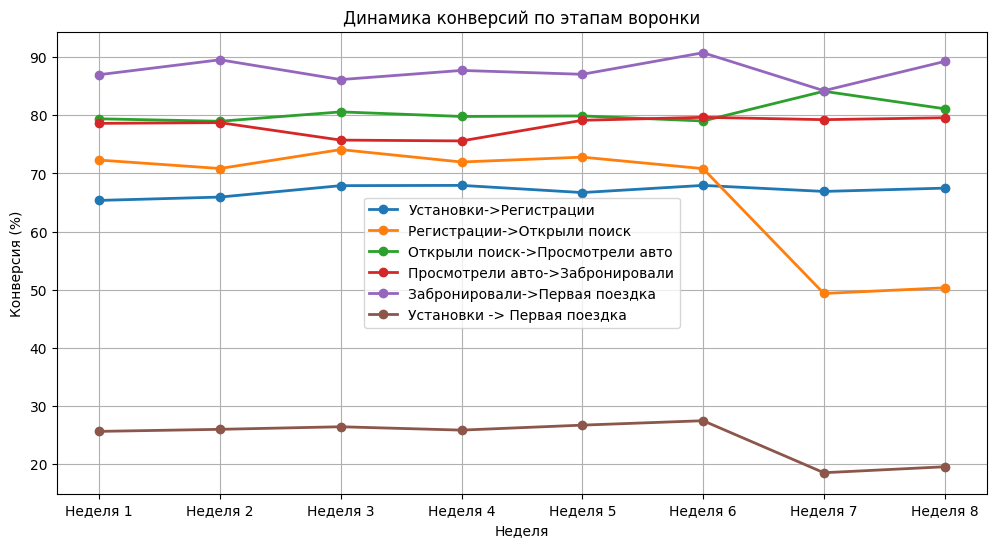

In [78]:
import matplotlib.pyplot as plt

cr_cols = weekly.columns[7:]

plt.figure(figsize=(12,6))

for col in cr_cols:
    plt.plot(
        weekly["Неделя"].iloc[1:],
        weekly[col].iloc[1:] * 100,
        marker="o",
        linewidth=2,
        label=col
    )

plt.title('Динамика конверсий по этапам воронки')
plt.xlabel('Неделя')
plt.ylabel('Конверсия (%)')
plt.grid()
plt.legend()

plt.show()